In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


In [6]:
import pandas as pd
df=pd.read_csv(r"C:\Users\User\Downloads\Compressed\titanic\train.csv")

df[['Survived', 'Sex', 'Age', 'Fare']].head()


,Survived,Sex,Age,Fare
0,0,male,22.0,7.2500
1,1,female,38.0,71.2833
2,1,female,26.0,7.9250
3,1,female,35.0,53.1000
4,0,male,35.0,8.0500


In [ ]:
df = pd.read_csv(r"C:\Users\User\Downloads\Compressed\titanic\gender_submission.csv")
df=pd.read_csv(r"C:\Users\User\Downloads\Compressed\titanic\test.csv")

In [7]:
df = df[['Survived', 'Sex', 'Age', 'Fare']]
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Sex       891 non-null    object 
 2   Age       714 non-null    float64
 3   Fare      891 non-null    float64
dtypes: float64(2), int64(1), object(1)
memory usage: 28.0+ KB
None


In [8]:
df['Age'].fillna(df['Age'].median(), inplace=True)



C:\Users\User\AppData\Local\Temp\ipykernel_22596\2404743633.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)


In [9]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})


In [10]:
X = df[['Age', 'Sex', 'Fare']]
y = df['Survived']



In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [12]:
model_no_scale = LogisticRegression(max_iter=1000)
model_no_scale.fit(X_train, y_train)

y_pred_no_scale = model_no_scale.predict(X_test)


In [13]:
print("Accuracy (No Scaling):", accuracy_score(y_test, y_pred_no_scale))
print(classification_report(y_test, y_pred_no_scale))


Accuracy (No Scaling): 0.776536312849162
              precision    recall  f1-score   support

           0       0.80      0.83      0.81       105
           1       0.74      0.70      0.72        74

    accuracy                           0.78       179
   macro avg       0.77      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



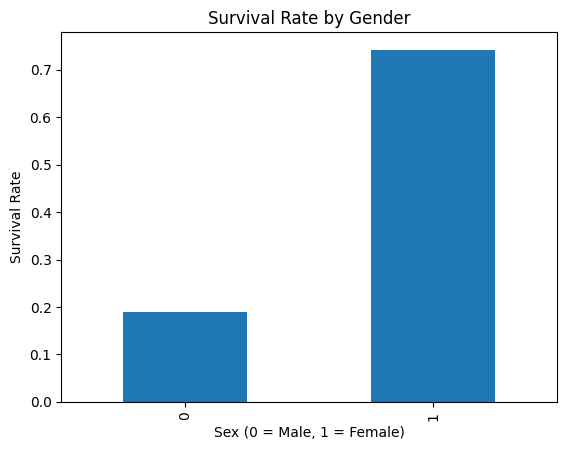

In [15]:

df.groupby('Sex')['Survived'].mean().plot(kind='bar')
plt.xlabel("Sex (0 = Male, 1 = Female)")
plt.ylabel("Survival Rate")
plt.title("Survival Rate by Gender")
plt.show()


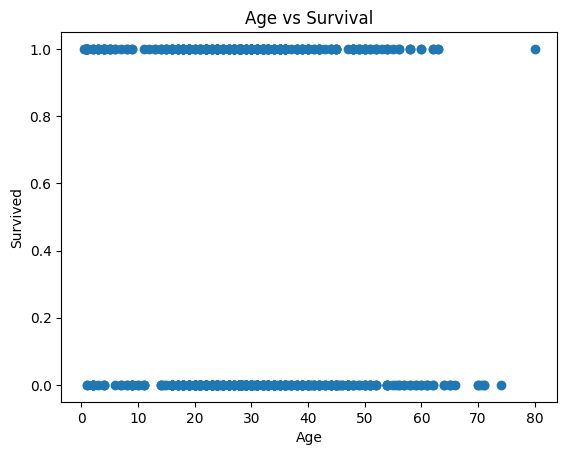

In [16]:
plt.scatter(df['Age'], df['Survived'])
plt.xlabel("Age")
plt.ylabel("Survived")
plt.title("Age vs Survival")
plt.show()


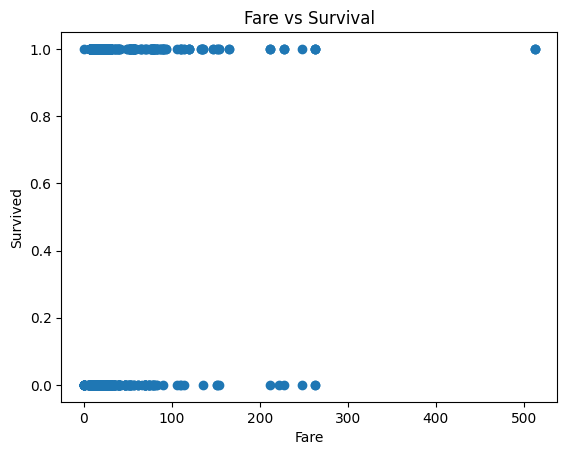

In [17]:
plt.scatter(df['Fare'], df['Survived'])
plt.xlabel("Fare")
plt.ylabel("Survived")
plt.title("Fare vs Survival")
plt.show()
